#  Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('../data/raw_listings.csv')

In [2]:
df.sample(10)

,name,url,price,mileage,location
13493,04 Infiniti Fx35,https://www.craigslist.org/view/d/atlanta-04-i...,2500,167000.0,city of atlanta
14924,2014 Nissan Murano S,https://www.craigslist.org/view/d/mesa-2014-ni...,5600,144000.0,e valley
1122,"2019 Honda Odyssey, Clean Title, One Owner",https://www.craigslist.org/view/d/hayward-2019...,16990,154000.0,hayward/castrovalley
14766,2019 Chevy Express Cargo Van,https://www.craigslist.org/view/d/mesa-2019-ch...,12950,120000.0,mesa
9361,2020 Acura Mdx Sh-4Wd,https://www.craigslist.org/view/d/chicago-2020...,20999,77000.0,city of chicago
387,2016 Chevrolet 2500,https://www.craigslist.org/view/d/el-verano-20...,16500,142000.0,sonoma
7696,2016 Land Rover Range Rover Sport,https://www.craigslist.org/view/d/tacoma-2016-...,10750,124000.0,tacoma / pierce
9350,2006 Ford Focus Zx3,https://www.craigslist.org/view/d/oak-forest-2...,1600,150000.0,oak forest
9850,2011 Toyota 4Runner Sr5 Rwd – One Owner – 128K...,https://www.craigslist.org/view/d/dallas-2011-...,21599,128000.0,north dallas
14241,C 2 Chevrolet Corvette 1963 Roadster/ Projec...,https://www.craigslist.org/view/d/danvers-2-ch...,22000,100000.0,danvers


In [3]:
df.describe()

,price,mileage
count,1.567600e+04,1.565800e+04
mean,8.196360e+04,1.354116e+05
std,8.026677e+06,2.397141e+05
min,1.000000e+00,1.000000e+00
25%,4.200000e+03,8.100000e+04
50%,7.500000e+03,1.250000e+05
75%,1.399925e+04,1.700000e+05
max,1.000000e+09,1.000000e+07


# EDA & Data Cleaning

### Feature Cleaning: Location

In [4]:
df['location'] = df['location'].astype(str).str.split('/').str[0].str.lower().str.strip()

In [5]:
df.sample(10)

,name,url,price,mileage,location
11661,2002 Porsche Boxster,https://www.craigslist.org/view/d/lake-worth-2...,15000,56000.0,lantana
9235,2010 Chevy Impala Ltz 130K Miles,https://www.craigslist.org/view/d/schaumburg-2...,3400,140000.0,schaumburg
7756,"Lexus Rx 300 Sport Utility 4Wd, 2001",https://www.craigslist.org/view/d/seahurst-lex...,3300,255000.0,burien
1536,2004 Saturn Ion 3 Coupe,https://www.craigslist.org/view/d/san-jose-200...,990,143000.0,campbell
7901,1998 Cadillac Concours,https://www.craigslist.org/view/d/marysville-1...,3900,209000.0,marysville
10174,2011 Toyota Camry Le…Clean Carfax,https://www.craigslist.org/view/d/grand-prairi...,3950,221000.0,grand prairie
3355,White 2014 Mitsubishi Outlander 1 Driver 101K ...,https://www.craigslist.org/view/d/san-francisc...,6800,102000.0,san francisco
8768,2008 Chevy Uplander,https://www.craigslist.org/view/d/algonquin-20...,4900,106000.0,lake in the hills
11851,2017 Ford Edge,https://www.craigslist.org/view/d/boca-raton-2...,14500,24000.0,"lake worth beach, florida"
7863,Brand New Grand Trek Tires,https://www.craigslist.org/view/d/federal-way-...,550,55.0,federal lway


### Univariate Analysis & Outliers

In [6]:
print(df[['price', 'mileage']].describe())

              price       mileage
count  1.567600e+04  1.565800e+04
mean   8.196360e+04  1.354116e+05
std    8.026677e+06  2.397141e+05
min    1.000000e+00  1.000000e+00
25%    4.200000e+03  8.100000e+04
50%    7.500000e+03  1.250000e+05
75%    1.399925e+04  1.700000e+05
max    1.000000e+09  1.000000e+07


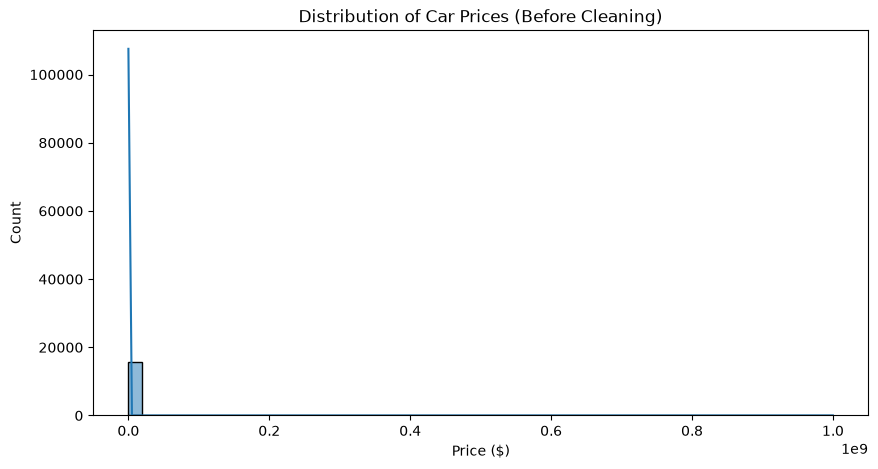

In [7]:
# Plot price distribution

plt.figure(figsize=(10, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Before Cleaning)')
plt.xlabel('Price ($)')
plt.show()

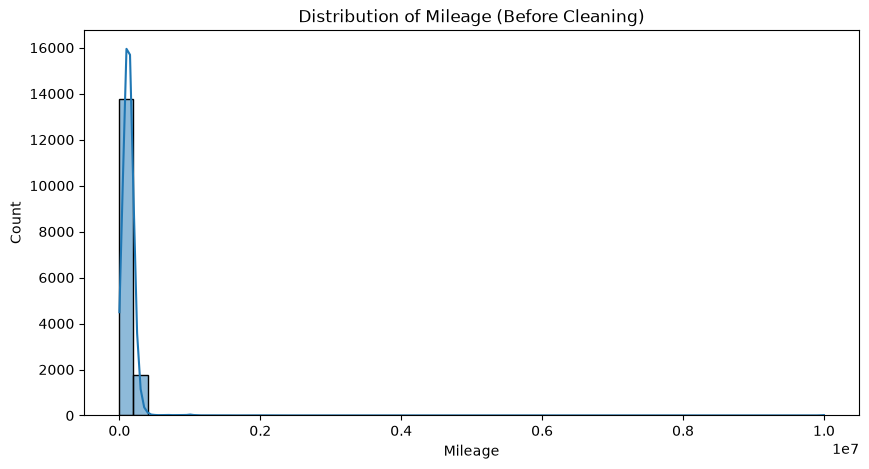

In [8]:
# Plot Mileage distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (Before Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [9]:
# 1. Define the realistic bounds for vehicles
MIN_PRICE = 800
MAX_PRICE = 100000
MIN_MILEAGE = 100
MAX_MILEAGE = 300000

# 2. Filter the DataFrame
df_clean = df[
    (df['price'] >= MIN_PRICE) & 
    (df['price'] <= MAX_PRICE) &
    (df['mileage'] >= MIN_MILEAGE) & 
    (df['mileage'] <= MAX_MILEAGE)
].copy()

# Drop any remaining rows where mileage or price might be NaN
df_clean = df_clean.dropna(subset=['price', 'mileage'])

print(f"Rows before trimming: {len(df)}")
print(f"Rows after trimming: {len(df_clean)}")

# New mathematical summary
print(df_clean[['price', 'mileage']].describe())

Rows before trimming: 15676
Rows after trimming: 14974
               price        mileage
count   14974.000000   14974.000000
mean    11302.086350  124626.061239
std     11555.058002   61802.240297
min       800.000000     100.000000
25%      4400.000000   82000.000000
50%      7600.000000  124000.000000
75%     14000.000000  167000.000000
max    100000.000000  300000.000000


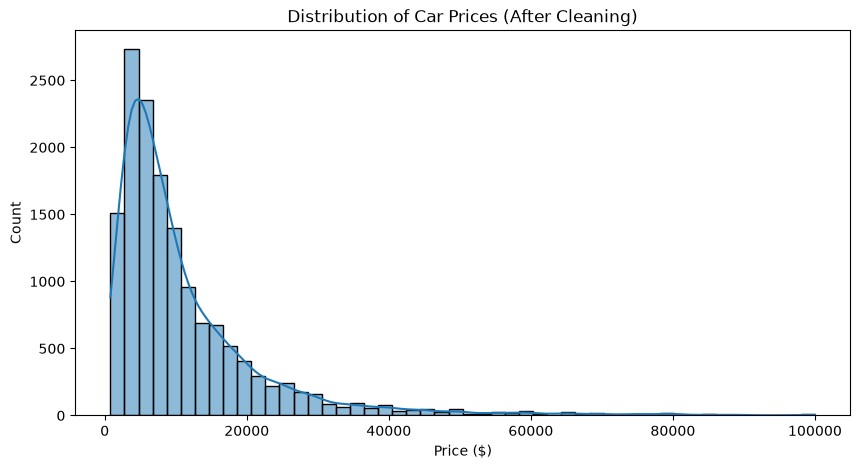

In [10]:
# Plot price distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (After Cleaning)')
plt.xlabel('Price ($)')
plt.show()

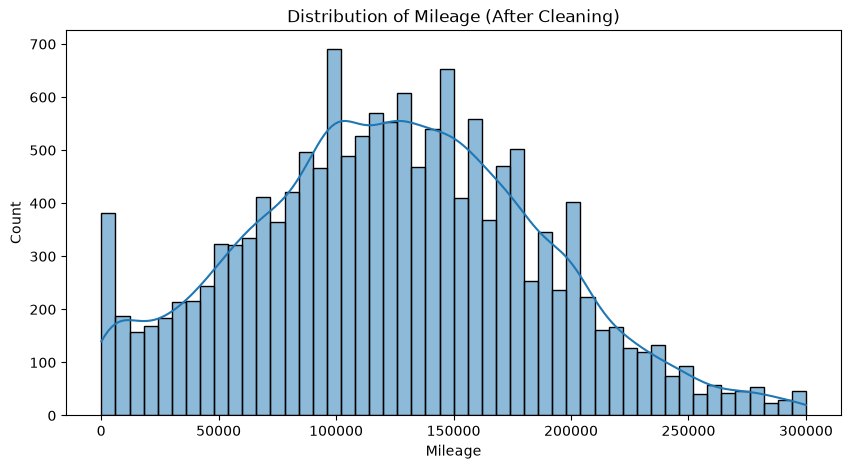

In [11]:
# Plot Mileage distribution (after)

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['mileage'].dropna(), bins=50, kde=True)
plt.title('Distribution of Mileage (After Cleaning)')
plt.xlabel('Mileage')
plt.show()

In [12]:
# 1. Define a list of common car manufacturers
manufacturers = [
    'Toyota', 'Honda', 'Ford', 'Chevrolet', 'Chevy', 'Nissan', 'BMW', 'Mercedes', 'Benz', 
    'Audi', 'Lexus', 'Subaru', 'Volkswagen', 'Vw', 'Hyundai', 'Kia', 'Mazda', 'Acura', 'Jeep', 
    'Dodge', 'Ram', 'GMC', 'Cadillac', 'Infiniti', 'Volvo', 'Mitsubishi', 'Mini',
    'Porsche', 'Tesla', 'Land Rover', 'Jaguar', 'Chrysler', 'Buick', 'Pontiac', 'Saturn'
]

In [13]:
def extract_make(title):
    # Lowercase the title to make matching case-insensitive
    title_lower = title.lower()
    
    # Loop through our list of manufacturers
    for make in manufacturers:
        # Check if the lowercased make is in the title
        if make.lower() in title_lower:
            return make.title() # Return it nicely formatted (e.g., "Honda")
            
    return None # If no manufacturer is found, return None

In [14]:
# 2. Apply the function to our 'name' column
df_clean['make'] = df_clean['name'].apply(extract_make)

print("Makes found:")
print(df_clean['make'].value_counts())

print("\nRows with missing Make:")
print(df_clean['make'].isnull().sum())

Makes found:
make
Ford          1793
Toyota        1610
Honda         1059
Nissan         890
Chevrolet      668
Mercedes       653
Chevy          639
Bmw            609
Dodge          539
Jeep           538
Lexus          368
Hyundai        344
Subaru         324
Gmc            285
Kia            236
Audi           228
Mazda          210
Volkswagen     209
Acura          205
Ram            185
Cadillac       183
Vw             149
Chrysler       128
Mini           128
Infiniti       116
Volvo          114
Buick          111
Pontiac        107
Porsche        100
Land Rover      82
Mitsubishi      79
Tesla           76
Jaguar          76
Saturn          27
Benz            16
Name: count, dtype: int64

Rows with missing Make:
1890


In [15]:
# Look at the ones it couldn't find to see if we missed any brands
missing_makes = df_clean[df_clean['make'].isnull()]
print("\nSample titles with missing makes:")
print(missing_makes['name'])


Sample titles with missing makes:
5        2019 Range Rover Sport Hse, Engine Disassemble...
6                                                Hummer H3
25                   2008 Mercury Grand Marquis Ls - $5800
42                                 2007 Nissam Frontier Xe
46                                      1967 Citroen Diane
                               ...                        
15647    2024 Range Rover Evoque S – 32,000 Miles – Cle...
15659                                            F150 2007
15664    23 Corvette Stingray Convertible 2Lt, Z51 3700...
15666                                          1979 Mg Mgb
15668                                  Infinity Qx50 Sport
Name: name, Length: 1890, dtype: str


In [16]:
# Drop rows where we still couldn't find the make
df_clean = df_clean.dropna(subset=['make'])

print(f"Final clean dataset size: {len(df_clean)} rows")

Final clean dataset size: 13084 rows


In [17]:
df_clean

,name,url,price,mileage,location,make
0,2015 Buick Regal Premium Ii Turbo - Only 52K M...,https://www.craigslist.org/view/d/san-bruno-20...,9975,52000.0,sanbruno,Buick
1,2012 Vw Gti,https://www.craigslist.org/view/d/watsonville-...,6000,150000.0,watsonville,Vw
2,Volvo,https://www.craigslist.org/view/d/forestville-...,21500,78000.0,russianriver,Volvo
3,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi
4,Modified 2011 Toyota Tacoma Trd Sport Double Cab,https://www.craigslist.org/view/d/san-rafael-m...,25000,98000.0,sanrafael,Toyota
...,...,...,...,...,...,...
15670,1996 Dodge Ram Van Wagon 2500,https://www.craigslist.org/view/d/peoria-1996-...,12000,202000.0,peoria,Dodge
15671,2007 Bmw 550I,https://www.craigslist.org/view/d/luke-air-for...,3500,190000.0,goodyear,Bmw
15673,Jaguar Xf Fully Loaded 2010-Premium,https://www.craigslist.org/view/d/glendale-jag...,14000,61000.0,glendale,Jaguar
15674,Hyundai Elantra 2016 Value Edition,https://www.craigslist.org/view/d/glendale-hyu...,15000,10000.0,glendale,Hyundai


In [18]:
# 1. Define a dictionary mapping Makes to their most popular models
car_models_dict = {
    'Toyota': ['Camry', 'Corolla', 'Prius', 'Sienna', 'Tacoma', 'Tundra', 'Rav4', 'Highlander', '4Runner', 'Avalon', 'Yaris', 'Sequoia', 'Matrix', 'Fj Cruiser', 'Venza', 'Mirai', 'C-Hr', 'C-HR', 'Supra', 'Land Cruiser', 'Celica', 'MR2', 'Echo', 'Solara', 'Paseo', 'Previa', 'MR2 Spyder', 'Tercel', 'Camry Solara', 'Cressida', 'Venza', 'Corolla Hatchback', 'Corolla Cross', 'Corolla Hybrid', 'Camry Hybrid', 'Rav4 Hybrid', 'Highlander Hybrid', 'Sienna Hybrid', 'Tacoma TRD', 'Tundra TRD',],
    'Honda': ['Civic', 'Accord', 'Cr-v', 'Crv', 'Odyssey', 'Pilot', 'Fit', 'Hr-v', 'Hrv', 'Element', 'Ridgeline', 'Insight', 'Passport', 'S2000', 'Prelude', 'Clarity', 'Crosstour', 'Del Sol', 'S2000', 'CR-Z', 'NSX', 'Integra', 'Vigor', 'Ascot', 'Civic Si', 'Accord Hybrid', 'CR-V Hybrid', 'Insight Hybrid', 'Clarity Plug-in', 'Clarity Electric', 'Fit EV', 'HR-V Sport', 'Ridgeline Black Edition', 'Odyssey Elite', 'Pilot Black Edition', 'Civic Type R', 'Accord Sport', 'CR-V Touring', 'HR-V EX-L', 'Fit Sport', 'Ridgeline RTL-E', 'Odyssey Touring', 'Pilot Touring'],
    'Ford': ['F150', 'F-150', 'F250', 'F-250', 'F350', 'F-350', 'Escape', 'Explorer', 'Focus', 'Fusion', 'Mustang', 'Edge', 'Transit', 'Ranger', 'Expedition', 'Taurus', 'Bronco', 'Flex', 'EcoSport', 'C-Max', 'Fiesta', 'GT', 'Lightning', 'Maverick', 'Thunderbird', 'Econoline', 'Excursion', 'Windstar', 'Probe', 'Tempo', 'Aspire', 'Contour', 'Escape Hybrid', 'Fusion Hybrid', 'C-Max Hybrid', 'Transit Connect', 'Transit Connect Wagon', 'Transit Connect Van', 'Transit Connect Cargo', 'Transit Connect Passenger', 'Transit Connect XL', 'Transit Connect XLT', 'Transit Connect Titanium', 'Transit Connect Limited', 'Transit Connect Sport', 'Transit Connect SE', 'Transit Connect SEL', 'Transit Connect LWB', 'Transit Connect SWB'],
    'Chevrolet': ['Silverado', 'Equinox', 'Malibu', 'Cruze', 'Tahoe', 'Impala', 'Colorado', 'Camaro', 'Corvette', 'Suburban', 'Traverse', 'Spark', 'Sonic', 'Volt', 'Bolt', 'Trax', 'Blazer', 'Express', 'Avalanche', 'SSR', 'HHR', 'Cobalt', 'Caprice', 'Lumina', 'Monte Carlo', 'Uplander', 'Venture', 'Astro', 'Tracker', 'S-10', 'G-Series Van', 'G-Series Truck', 'K-Series Truck', 'R-Series Truck', 'S-10 Blazer', 'S-10 Pickup', 'C/K Series', 'Chevelle', 'Nova', 'El Camino', 'Bel Air', 'Impala SS', 'Caprice Classic', 'Monte Carlo SS', 'Camaro ZL1', 'Corvette Z06', 'Silverado HD', 'Colorado ZR2', 'Tahoe RST', 'Suburban RST'],
    'Nissan': ['Altima', 'Sentra', 'Rogue', 'Maxima', 'Murano', 'Pathfinder', 'Versa', 'Frontier', 'Titan', 'Armada', 'Leaf', '350Z', '370Z', 'Juke', 'Kicks', 'GT-R', 'Xterra', 'Cube', 'Quest', 'NV200', 'NV1500', 'NV2500', 'NV3500', 'NV Cargo', 'NV Passenger', 'NV Van', 'NV Wagon', 'NV200 Compact Cargo', 'NV200 Compact Passenger', 'NV200 Compact Van', 'NV200 Compact Wagon', 'NV200 Compact Truck', 'NV200 Compact SUV', 'NV200 Compact Crossover', 'NV200 Compact Minivan', 'NV200 Compact Pickup', 'NV200 Compact Utility', 'NV200 Compact Commercial', 'NV200 Compact Fleet', 'NV200 Compact Delivery', 'NV200 Compact Service', 'NV200 Compact Work', 'NV200 Compact Business', 'NV200 Compact Professional', 'NV200 Compact Industrial', 'NV200 Compact Construction', 'NV200 Compact Maintenance', 'NV200 Compact Repair', 'NV200 Compact Technician', 'NV200 Compact Installer', 'NV200 Compact Operator'],
    'Bmw': ['328I', '335I', '325I', 'X5', 'X3', 'M3', 'M4', 'M5', '528I', '535I', '750Li', 'X1', 'X6', 'Z4', 'I3', 'I8', 'M2', 'M6', 'X4', 'X7', '330I', '340I', '430I', '440I', '530I', '540I', '640I', '650I', '740I', '750I', '840I', '850I', 'M550I', 'M760I', 'X2', 'X5 M', 'X6 M', 'Z3', 'Z8', 'I4', 'I5', 'I6', 'I7', 'I8 Roadster', 'M1', 'M3 E30', 'M3 E36', 'M3 E46', 'M3 E92', 'M4 GTS', 'M5 E28', 'M5 E34', 'M5 E39', 'M5 E60', 'M6 E63', 'M6 E64', 'M6 F12', 'M6 F13', 'M8', 'X3 M', 'X4 M', 'X5 M50i', 'X6 M50i', 'Z4 M40i'],
    'Mercedes': ['C300', 'E350', 'E320', 'E300', 'Ml350', 'Glk350', 'S550', 'S500', 'Gle', 'Glc', 'Gla', 'Sprinter', 'C63', 'Amg', 'C230', 'C240', 'C250', 'C280', 'C320', 'C350', 'E320', 'E350', 'E500', 'E550', 'S430', 'S500', 'S550', 'S600', 'S63', 'S65', 'G550', 'G63', 'G65', 'Gla250', 'Glc300', 'Glc43', 'Gle350', 'Gle43', 'Metris', 'Sprinter 2500', 'Sprinter 3500', 'Sprinter 2500 Cargo', 'Sprinter 3500 Cargo', 'Sprinter 2500 Passenger', 'Sprinter 3500 Passenger', 'Sprinter 2500 Crew', 'Sprinter 3500 Crew', 'Sprinter 2500 Van', 'Sprinter 3500 Van', 'Sprinter 2500 Chassis', 'Sprinter 3500 Chassis', 'Sprinter 2500 Cab', 'Sprinter 3500 Cab'],
    'Subaru': ['Outback', 'Forester', 'Impreza', 'Legacy', 'Crosstrek', 'Wrx', 'Brz', 'Ascent', 'Tribeca', 'Baja', 'Justy', 'Alcyone', 'Vivio', 'Sambar', 'R1', 'R2', 'Exiga', 'Trezia', 'Levorg', 'WRX STI', 'WRX Premium', 'WRX Limited', 'WRX Base', 'WRX Sport', 'WRX Touring', 'WRX Series.Gray', 'WRX Series.Blue', 'WRX Series.Red', 'WRX Series.White', 'WRX Series.Black', 'WRX Series.Silver', 'WRX Series.Gold', 'WRX Series.Green', 'WRX Series.Yellow', 'WRX Series.Orange', 'WRX Series.Purple', 'WRX Series.Bronze', 'WRX Series.Copper', 'WRX Series.Platinum', 'WRX Series.Titanium', 'WRX Series.Carbon', 'WRX Series.Aluminum', 'WRX Series.Steel', 'WRX Series.Iron', 'WRX Series.Nickel', 'WRX Series.Chrome'],
    'Volkswagen': ['Jetta', 'Passat', 'Golf', 'Gti', 'Tiguan', 'Touareg', 'Atlas', 'Beetle', 'Arteon', 'CC', 'Eos', 'R32', 'Scirocco', 'Vanagon', 'Eurovan', 'Rabbit', 'Fox', 'Dasher', 'Thing', 'Karmann Ghia', 'Phaeton', 'New Beetle', 'New Beetle Convertible', 'Golf R', 'Golf Alltrack', 'Golf SportWagen', 'Golf GTI', 'Golf TDI', 'Golf R32', 'Golf R-Line', 'Golf SE', 'Golf SEL', 'Golf S', 'Golf Wolfsburg Edition', 'Golf GTI Rabbit Edition', 'Golf GTI Autobahn', 'Golf GTI Performance', 'Golf GTI S', 'Golf GTI SE', 'Golf GTI SEL', 'Golf GTI Wolfsburg Edition', 'Golf GTI Clubsport', 'Golf GTI TCR', 'Golf GTI Edition 35', 'Golf GTI Edition 30', 'Golf GTI Edition 20', 'Golf GTI Edition 10', 'Golf GTI Edition 5', 'Golf GTI Edition 1'],
    'Vw': ['Jetta', 'Passat', 'Golf', 'Gti', 'Tiguan', 'Touareg', 'Atlas', 'Beetle', 'Arteon', 'CC', 'Eos', 'R32', 'Scirocco', 'Vanagon', 'Eurovan', 'Rabbit', 'Fox', 'Dasher', 'Thing', 'Karmann Ghia', 'Phaeton', 'New Beetle', 'New Beetle Convertible', 'Golf R', 'Golf Alltrack', 'Golf SportWagen', 'Golf GTI', 'Golf TDI', 'Golf R32', 'Golf R-Line', 'Golf SE', 'Golf SEL', 'Golf S', 'Golf Wolfsburg Edition', 'Golf GTI Rabbit Edition', 'Golf GTI Autobahn', 'Golf GTI Performance', 'Golf GTI S', 'Golf GTI SE', 'Golf GTI SEL', 'Golf GTI Wolfsburg Edition', 'Golf GTI Clubsport', 'Golf GTI TCR', 'Golf GTI Edition 35', 'Golf GTI Edition 30', 'Golf GTI Edition 20', 'Golf GTI Edition 10', 'Golf GTI Edition 5', 'Golf GTI Edition 1'],
    'Lexus': ['Rx', 'Es', 'Is', 'Nx', 'Gx', 'Lx', 'Gs', 'Ls', 'Ct', 'Rc', 'Ux', 'Lfa', 'Rx Hybrid', 'Es Hybrid', 'Is F', 'Gs F', 'Ls F', 'Rc F', 'Ux Hybrid', 'Nx Hybrid', 'Gx 460', 'Gx 470', 'Lx 570', 'Rx 350', 'Rx 450h', 'Es 350', 'Es 300h', 'Is 250', 'Is 350', 'Gs 350', 'Gs 450h', 'Ls 460', 'Ls 600h', 'Rc 350', 'Rc F', 'Ux 200', 'Ux 250h'],
    'Audi': ['A4', 'A6', 'Q5', 'Q7', 'A3', 'S4', 'Tt', 'Q3', 'S5', 'S3', 'A5', 'A7', 'A8', 'Q8', 'R8', 'E-Tron', 'E-Tron Sportback', 'E-Tron GT', 'E-Tron Quattro', 'E-Tron 55', 'E-Tron 50', 'E-Tron 40', 'E-Tron 35', 'E-Tron 30', 'E-Tron 25', 'E-Tron 20', 'E-Tron 15', 'E-Tron 10'],
    'Jeep': ['Grand Cherokee', 'Wrangler', 'Cherokee', 'Compass', 'Renegade', 'Patriot', 'Gladiator', 'Commander', 'Liberty', 'Wagoneer', 'Grand Wagoneer', 'Cherokee Trailhawk', 'Cherokee Latitude', 'Cherokee Limited', 'Cherokee Overland', 'Cherokee High Altitude', 'Cherokee Altitude', 'Cherokee Sport', 'Cherokee North Edition', 'Cherokee Freedom Edition', 'Cherokee Upland Edition', 'Cherokee 80th Anniversary Edition', 'Wrangler Unlimited', 'Wrangler Rubicon', 'Wrangler Sahara', 'Wrangler Sport', 'Wrangler Willys Wheeler', 'Wrangler Freedom Edition', 'Wrangler Islander Edition'],
    'Hyundai': ['Elantra', 'Sonata', 'Tucson', 'Santa Fe', 'Accent', 'Kona', 'Palisade', 'Veloster', 'Genesis', 'Ioniq', 'Venue', 'Nexo', 'Azera', 'Entourage', 'Equus', 'Excel', 'Scoupe', 'Sante Fe Sport', 'Sante Fe XL', 'Tiburon', 'XG350', 'XG300', 'Veloster N', 'Kona N', 'Ioniq Hybrid', 'Ioniq Electric', 'Ioniq Plug-in Hybrid', 'Genesis G70', 'Genesis G80', 'Genesis G90', 'Genesis GV70', 'Genesis GV80'],
    'Kia': ['Optima', 'Sorento', 'Soul', 'Forte', 'Sportage', 'Telluride', 'Sedona', 'Rio', 'Stinger', 'Cadenza', 'Seltos', 'Niro', 'K900', 'Amanti', 'Carens', 'Cerato', 'Mohave', 'Opirus', 'Pride', 'Sephia', 'Shuma', 'Spectra', 'Venga', 'XCeed', 'EV6', 'Niro EV', 'Niro Plug-in Hybrid', 'Stonic', 'Sonet', 'Carnival', 'K5', 'K7', 'K8', 'K9', 'KX3', 'KX5', 'KX7', 'KX8', 'KX9', 'KX10', 'KX11', 'KX12', 'KX13', 'KX14', 'KX15', 'KX16', 'KX17', 'KX18', 'KX19', 'KX20'],
    'Mazda': ['Mazda3', 'Mazda6', 'Cx-5', 'Cx5', 'Cx-9', 'Cx9', 'Miata', 'Mx-5', 'Rx-8', 'Rx-7', 'B-Series', 'Tribute', '5', '2', '3 Hatchback', '3 Sedan', '6 Hatchback', '6 Sedan', 'Cx-30', 'Cx-50', 'Cx-90', 'Mx-30', 'Mx-5 Miata RF', 'Mx-5 Miata Club', 'Mx-5 Miata Grand Touring', 'Mx-5 Miata Sport', 'Mx-5 Miata Base', 'Mx-5 Miata Touring', 'Mx-5 Miata Premium', 'Mx-5 Miata Limited', 'Mx-5 Miata Special Edition', 'Mx-5 Miata Anniversary Edition', 'Mx-5 Miata 30th Anniversary Edition', 'Mx-5 Miata 25th Anniversary Edition', 'Mx-5 Miata 20th Anniversary Edition', 'Mx-5 Miata 15th Anniversary Edition', 'Mx-5 Miata 10th Anniversary Edition', 'Mx-5 Miata 5th Anniversary Edition'],
    'Dodge': ['Charger', 'Challenger', 'Grand Caravan', 'Durango', 'Journey', 'Dart', 'Ram 1500', 'Ram 2500', 'Ram 3500', 'Viper', 'Neon', 'Stratus', 'Avenger', 'Caliber', 'Nitro', 'Dakota', 'Magnum', 'Ram ProMaster', 'Ram ProMaster City', 'Ram Chassis Cab', 'Ram 1500 Classic', 'Ram 2500 Heavy Duty', 'Ram 3500 Heavy Duty', 'Ram 4500 Chassis Cab', 'Ram 5500 Chassis Cab', 'Ram 3500 Cab Chassis', 'Ram 4500 Cab Chassis', 'Ram 5500 Cab Chassis', 'Ram 1500 Tradesman', 'Ram 1500 Big Horn', 'Ram 1500 Laramie', 'Ram 1500 Rebel', 'Ram 1500 Limited', 'Ram 1500 Sport', 'Ram 1500 Warlock', 'Ram 2500 Tradesman', 'Ram 2500 Big Horn', 'Ram 2500 Laramie', 'Ram 2500 Power Wagon', 'Ram 2500 Limited', 'Ram 3500 Tradesman', 'Ram 3500 Big Horn', 'Ram 3500 Laramie', 'Ram 3500 Limited'],
    'Ram': ['1500', '2500', '3500', 'Promaster', 'Promaster City', 'Chassis Cab', '1500 Classic', '2500 Heavy Duty', '3500 Heavy Duty', '4500 Chassis Cab', '5500 Chassis Cab', '3500 Cab Chassis', '4500 Cab Chassis', '5500 Cab Chassis', '1500 Tradesman', '1500 Big Horn', '1500 Laramie', '1500 Rebel', '1500 Limited', '1500 Sport', '1500 Warlock', '2500 Tradesman', '2500 Big Horn', '2500 Laramie', '2500 Power Wagon', '2500 Limited', '3500 Tradesman', '3500 Big Horn', '3500 Laramie', '3500 Limited', 'Promaster 1500', 'Promaster 2500', 'Promaster 3500', 'Promaster City 1500', 'Promaster City 2500', 'Promaster City 3500'],
    'Gmc': ['Sierra', 'Acadia', 'Terrain', 'Yukon', 'Canyon', 'Savana', 'Denali', 'Envoy', 'Jimmy', 'Sierra 1500', 'Sierra 2500', 'Sierra 3500', 'Sierra Denali', 'Sierra SLT', 'Sierra Elevation', 'Sierra AT4', 'Sierra Denali Ultimate', 'Sierra Denali Ultimate Edition', 'Sierra Denali Ultimate Edition 2021', 'Sierra Denali Ultimate Edition 2022', 'Sierra Denali Ultimate Edition 2023', 'Sierra Denali Ultimate Edition 2024', 'Sierra Denali Ultimate Edition 2025', 'Sierra Denali Ultimate Edition 2026', 'Sierra Denali Ultimate Edition 2027', 'Sierra Denali Ultimate Edition 2028', 'Sierra Denali Ultimate Edition 2029', 'Sierra Denali Ultimate Edition 2030', 'Sierra Denali Ultimate Edition 2031', 'Sierra Denali Ultimate Edition 2032', 'Sierra Denali Ultimate Edition 2033', 'Sierra Denali Ultimate Edition 2034', 'Sierra Denali Ultimate Edition 2035', 'Sierra Denali Ultimate Edition 2036', 'Sierra Denali Ultimate Edition 2037', 'Sierra Denali Ultimate Edition 2038', 'Sierra Denali Ultimate Edition 2039', 'Sierra Denali Ultimate Edition 2040'],
    'Tesla': ['Model 3', 'Model Y', 'Model S', 'Model X', 'Cybertruck', 'Roadster', 'Semi', 'Model 3 Performance', 'Model 3 Long Range', 'Model 3 Standard Range Plus', 'Model Y Performance', 'Model Y Long Range', 'Model Y Standard Range', 'Model S Plaid', 'Model S Long Range', 'Model S Standard Range', 'Model X Plaid', 'Model X Long Range', 'Model X Standard Range', 'Cybertruck Tri Motor', 'Cybertruck Dual Motor', 'Cybertruck Single Motor', 'Roadster Sport', 'Roadster Base', 'Semi Long Range', 'Semi Standard Range'],
    'Mini': ['Cooper', 'Countryman', 'Clubman', 'Hardtop', 'Paceman', 'Cooper S', 'Cooper SE', 'Cooper JCW', 'Cooper Convertible', 'Cooper Roadster', 'Cooper Coupe', 'Cooper Clubman S', 'Cooper Countryman S', 'Cooper Paceman S', 'Cooper Hardtop S', 'Cooper Convertible S', 'Cooper Roadster S', 'Cooper Coupe S', 'Cooper Clubman JCW', 'Cooper Countryman JCW', 'Cooper Paceman JCW', 'Cooper Hardtop JCW', 'Cooper Convertible JCW', 'Cooper Roadster JCW', 'Cooper Coupe JCW'],
    'Acura': ['Mdx', 'Rdx', 'Tlx', 'Ilx', 'Integra', 'Tsx', 'Tl', 'Rsx', 'Rl', 'Rlx', 'Zdx', 'Nsx', 'Mdx Sport Hybrid', 'Rdx A-Spec', 'Tlx Type S', 'Ilx Premium', 'Integra Type R', 'Tsx Wagon', 'Tl Type S', 'Rsx Type S', 'RlX Advance', 'Rlx Sport Hybrid', 'Zdx Technology', 'Nsx Type S', 'Mdx Advance', 'Rdx Advance', 'Tlx Advance', 'Ilx Advance', 'Integra Advance', 'Tsx Advance', 'Tl Advance', 'Rsx Advance', 'RlX Advance', 'Rlx Advance', 'Zdx Advance', 'Nsx Advance'],
    'Lucid': ['Air', 'Gravity', 'Aero', 'Air Touring', 'Air Grand Touring', 'Air Dream Edition', 'Air Pure', 'Air Sapphire', 'Air Performance', 'Air Base', 'Air Plus', 'Air Max', 'Air Ultra', 'Air Elite', 'Air Signature', 'Air Limited', 'Air Special Edition'],
    'Rivian': ['R1T', 'R1S', 'R2T', 'R2S', 'R3T', 'R3S', 'R4T', 'R4S', 'R5T', 'R5S', 'R6T', 'R6S', 'R7T', 'R7S', 'R8T', 'R8S'],
    'Polestar': ['Polestar 2', 'Polestar 3', 'Polestar 1', 'Polestar 4', 'Polestar 5'], 
    'Fisker': ['Ocean', 'Karma'],
    'Cadillac': ['Escalade', 'Cts', 'Ats', 'Xt5', 'Xt4', 'Srx', 'Xts', 'Deville', 'Seville', 'Eldorado', 'Fleetwood', 'Brougham', 'Allante', 'Cimarron', 'Dts', 'Sts', 'Catera', 'Xlr', 'Escalade ESV', 'Escalade EXT', 'Escalade Platinum', 'Escalade Luxury', 'Escalade Premium Luxury'],
    'Infiniti': ['G37', 'G35', 'Q50', 'Qx60', 'Qx80', 'Q60', 'Fx35', 'M35', 'Qx50', 'Qx70', 'Qx30', 'Qx56', 'Qx4', 'I30', 'I35', 'J30', 'M45', 'Q45', 'Ex35', 'Ex37', 'Ex25', 'Ex30', 'Ex20', 'Ex15', 'Ex10', 'Ex5', 'Ex3', 'Ex2', 'Ex1', 'Qx90', 'Qx100', 'Qx110', 'Qx120', 'Qx130', 'Qx140', 'Qx150', 'Qx160', 'Qx170', 'Qx180', 'Qx190'],
    'Volvo': ['Xc90', 'Xc60', 'Xc40', 'S60', 'S90', 'V60', 'V90', 'C30', 'C70', 'S40', 'S80', 'V40', 'V50', 'V70', 'V90 Cross Country', 'Xc90 T8', 'Xc60 T8', 'Xc40 Recharge', 'S60 Recharge', 'S90 Recharge', 'V60 Recharge', 'V90 Recharge', 'C30 Electric', 'C70 Electric', 'S40 Electric', 'S80 Electric', 'V40 Electric', 'V50 Electric', 'V70 Electric'],
    'Mitsubishi': ['Outlander', 'Lancer', 'Eclipse', 'Mirage', 'Galant', 'Endeavor', 'Montero', 'Pajero', 'Raider', 'Diamante', 'Challenger', 'Cordia', 'Starion', 'Precis', 'Tredia', 'Sigma', 'Sapporo', 'GTO', '3000GT', 'Eclipse Spyder', 'Lancer Evolution', 'Outlander Sport', 'Outlander PHEV'],
    'Porsche': ['911', 'Cayenne', 'Macan', 'Panamera', 'Boxster', 'Cayman', 'Taycan', '918 Spyder', 'Carrera', 'Turbo', 'GT3', 'GT2', 'GT4', 'Cayenne S', 'Cayenne GTS', 'Cayenne Turbo', 'Macan S', 'Macan GTS', 'Macan Turbo', 'Panamera 4S', 'Panamera Turbo', 'Panamera GTS', 'Panamera E-Hybrid', 'Boxster S', 'Boxster GTS', 'Boxster Spyder', 'Cayman S', 'Cayman GTS', 'Cayman GT4', 'Taycan 4S', 'Taycan Turbo', 'Taycan Turbo S'],
    'Land Rover': ['Range Rover', 'Discovery', 'Defender', 'Evoque', 'Lr4', 'Lr3', 'Freelander', 'Discovery Sport', 'Range Rover Sport', 'Range Rover Velar', 'Range Rover Evoque', 'Range Rover Autobiography', 'Range Rover HSE', 'Range Rover SE', 'Range Rover SVAutobiography', 'Range Rover SVR', 'Range Rover LWB', 'Range Rover SWB', 'Range Rover PHEV'],
    'Jaguar': ['Xf', 'Xj', 'F-Type', 'F-Pace', 'E-Pace', 'I-Pace', 'Xe', 'S-Type', 'X-Type', 'XK', 'XKR', 'XJR', 'XFR', 'XFR-S', 'XJ8', 'XJ6', 'XJ12', 'XJ-S', 'XJ40', 'XJ6 Series II', 'XJ6 Series III', 'XJ6 Series IV', 'XJ6 Series V', 'XJ6 Series VI', 'XJ6 Series VII'],
    'Chrysler': ['300', 'Pacifica', 'Town & Country', 'Sebring', 'Pt Cruiser', 'Aspen', 'Crossfire', 'Voyager', 'Concorde', 'LHS', 'New Yorker', 'Cirrus', 'Saratoga', 'Imperial', 'Royal', 'Fifth Avenue', 'LeBaron', 'Newport', 'Town & Country Touring', 'Town & Country Limited', 'Town & Country LX', 'Town & Country Touring L', 'Town & Country Touring Plus'],
    'Buick': ['Enclave', 'Encore', 'Envision', 'Lacrosse', 'Regal', 'Lucerne', 'Rendezvous', 'Rainier', 'Terraza', 'Skyhawk', 'Skylark', 'Reatta', 'Electra', 'Century', 'LeSabre', 'Roadmaster', 'Park Avenue', 'Riviera', 'Gran Sport'],
    'Pontiac': ['Grand Prix', 'G6', 'Grand Am', 'Vibe', 'Firebird', 'G8', 'Bonneville', 'G5', 'G3', 'Solstice', 'Torrent', 'Aztek', 'Sunfire', 'Montana', 'Wave', 'Fiero', 'LeMans', 'Tempest', 'Catalina', 'Safari', 'Parisienne', 'GTO'],
    'Saturn': ['Vue', 'Ion', 'Aura', 'Sky', 'Outlook', 'L-Series', 'S-Series', 'SL', 'SC', 'SW', 'LW', 'VUE Red Line', 'VUE Green Line', 'VUE Hybrid', 'VUE Sport', 'VUE XR', 'VUE XE', 'VUE XRE', 'VUE XRS', 'VUE XRT', 'VUE XRV', 'VUE XRW', 'VUE XRX', 'VUE XRY', 'VUE XRZ'],
    'Bently': ['Continental', 'Flying Spur', 'Mulsanne', 'Arnage', 'Azure', 'Brooklands', 'Turbo R', 'Turbo S', 'Turbo RT', 'Turbo RT Speed', 'Turbo RT Mulliner', 'Turbo RT Le Mans', 'Turbo RT Le Mans Edition', 'Turbo RT Le Mans Edition 2005', 'Turbo RT Le Mans Edition 2006', 'Turbo RT Le Mans Edition 2007', 'Turbo RT Le Mans Edition 2008', 'Turbo RT Le Mans Edition 2009', 'Turbo RT Le Mans Edition 2010'],
}

def extract_model(title, make):
    if pd.isna(make):
        return None
        
    title_lower = title.lower()
    
    # If we have a list of models for this make, check if they exist in the title
    if make in car_models_dict:
        for model in car_models_dict[make]:
            if model.lower() in title_lower:
                # Standardize names (e.g., make 'Cr-v' into 'Crv')
                return model.replace('-', '').title() 
                
    return None

# Apply the new function
df_clean['model'] = df_clean.apply(lambda row: extract_model(row['name'], row['make']), axis=1)

# Drop rows where a legitimate model couldn't be found
df_clean = df_clean.dropna(subset=['model'])

In [19]:
# Apply the function
df_clean['model'] = df_clean.apply(lambda row: extract_model(row['name'], row['make']), axis=1)

# Drop rows where no model is found
df_clean = df_clean.dropna(subset=['model'])

In [20]:
# Check models
print(df_clean[['name', 'make', 'model']].sample(30))

                                                    name        make     model
2023                           For Sale 2008 Honda Civic       Honda     Civic
5090                    2026 Toyota Corolla Hatchback Se      Toyota   Corolla
14054                       2017 Hyundai Elantra Limited     Hyundai   Elantra
11357                                2005 Toyota 4Runner      Toyota   4Runner
160                                      2007 Gmc Sierra         Gmc    Sierra
666                    2010 Honda Civic Lx-S Sport Sedan       Honda     Civic
8231   2022 Ford F-150 Supercrew 5.0L V8 Crew Cab 4X4...        Ford      F150
15465          2018 Subaru Outback Premium Awd Low Miles      Subaru   Outback
7536                      1987 Ford F250 Lariat 7.5 L V8        Ford      F250
12508                                  2016 Toyota Camry      Toyota     Camry
13653                  2006 Toyota Sienna 174K One Owner      Toyota    Sienna
13577  1996 Ford Mustang Gt Triple Black Stick W/ 8K

In [21]:
import re

# Extract Year (Looks for 19xx or 20xx)
df_clean['year'] = df_clean['name'].str.extract(r'(\b(19[0-9]{2}|20[0-2][0-9])\b)')[0]

# Drop rows that didn't have a year in the title
df_clean = df_clean.dropna(subset=['year'])
df_clean['year'] = df_clean['year'].astype(int)

df_clean

,name,url,price,mileage,location,make,model,year
0,2015 Buick Regal Premium Ii Turbo - Only 52K M...,https://www.craigslist.org/view/d/san-bruno-20...,9975,52000.0,sanbruno,Buick,Regal,2015
1,2012 Vw Gti,https://www.craigslist.org/view/d/watsonville-...,6000,150000.0,watsonville,Vw,Gti,2012
3,2014 Audi A7 Prestige Quattro S Line | 3.0T Su...,https://www.craigslist.org/view/d/brentwood-20...,8900,189000.0,brentwood,Audi,Tt,2014
4,Modified 2011 Toyota Tacoma Trd Sport Double Cab,https://www.craigslist.org/view/d/san-rafael-m...,25000,98000.0,sanrafael,Toyota,Tacoma,2011
7,2019 Nissan Rogue Sport Awd,https://www.craigslist.org/view/d/lafayette-20...,14000,75000.0,concord,Nissan,Rogue,2019
...,...,...,...,...,...,...,...,...
15665,Chevrolet Traverse Lt 2021,https://www.craigslist.org/view/d/tolleson-che...,16900,87000.0,tolleson,Chevrolet,Traverse,2021
15669,2001 Lexus Gs300 - Exceptional Condition,https://www.craigslist.org/view/d/mesa-2001-le...,16500,162000.0,mesa,Lexus,Gs,2001
15673,Jaguar Xf Fully Loaded 2010-Premium,https://www.craigslist.org/view/d/glendale-jag...,14000,61000.0,glendale,Jaguar,Xf,2010
15674,Hyundai Elantra 2016 Value Edition,https://www.craigslist.org/view/d/glendale-hyu...,15000,10000.0,glendale,Hyundai,Elantra,2016


In [22]:
import datetime

# Get the current year
current_year = datetime.datetime.now().year

# Calculate age
df_clean['age'] = current_year - df_clean['year']

# Quick check
print(df_clean[['name', 'year', 'age']].head())

                                                name  year  age
0  2015 Buick Regal Premium Ii Turbo - Only 52K M...  2015   11
1                                        2012 Vw Gti  2012   14
3  2014 Audi A7 Prestige Quattro S Line | 3.0T Su...  2014   12
4   Modified 2011 Toyota Tacoma Trd Sport Double Cab  2011   15
7                        2019 Nissan Rogue Sport Awd  2019    7


In [23]:
df_clean.to_csv('../data/clean_listings.csv', index=False)

# Model Training & Evaluation

* Split data into Train (80%) and Test (20%).
* Apply One-Hot Encoding to categorical data (Make, Location).
* Train an XGBoost Regression model.

In [24]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/abhinav/Documents/AutoValuate/venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <010DE1F1-B66F-31D2-8EDA-A08913D25DDA> /Users/abhinav/Documents/AutoValuate/venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt

In [ ]:
# 1. Define Features (X) and Target (y) and perform train_test_split

X = df_clean[['age', 'make', 'model', 'mileage', 'location']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_encoded = ohe.fit_transform(X_train[['make', 'model', 'location']])
X_test_encoded = ohe.transform(X_test[['make', 'model', 'location']])

# Put the encoded arrays back into DataFrames so they have column names
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(), index=X_test.index)

# Drop the original text columns from X_train and X_test, keep only numbers (year, mileage)
X_train_num = X_train.drop(columns=['make', 'model', 'location'])
X_test_num = X_test.drop(columns=['make', 'model', 'location'])

# Combine the numerical columns and encoded columns together
X_train_final = pd.concat([X_train_num, X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded_df], axis=1)

print(f"Training data shape: {X_train_final.shape}")
print(f"Testing data shape: {X_test_final.shape}")

## Train the Model

In [ ]:
# Diagnostic check: What columns is the model actually seeing?
print("Columns being fed to the model:")
print(X_train_final.columns.tolist())

print("\nFirst 3 rows of training data:")
X_train_final.head(3)

In [ ]:
# Tuned XGBoost Model
model = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=8, 
    subsample=0.8,     # Uses 80% of data per tree to prevent overfitting
    colsample_bytree=0.8, # Uses 80% of features per tree
    random_state=42
)   

# Train the model!
model.fit(X_train_final, y_train)

In [ ]:
# Make predictions on our test set
predictions = model.predict(X_test_final)

# Calculate Mean Absolute Error (MAE) and R-Squared
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Performance:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-Squared (R2): {r2:.2f}")

# Visually compare actual vs predicted for the first 10 cars
comparison = pd.DataFrame({
    'Actual_Price': y_test.values[:10],
    'Predicted_Price': predictions[:10].astype(int),
    'Age': X_test['age'].values[:10],
    'Make': X_test['make'].values[:10],
    'Model': X_test['model'].values[:10],
    'Mileage': X_test['mileage'].values[:10]
})
print("\nSample Predictions vs Actuals:")
print(comparison)

# Export the model using Pickle

In [ ]:
import joblib
import os

os.makedirs('../api', exist_ok=True)

# Save the XGBoost model
joblib.dump(model, '../api/model.pkl')

# Save the One-Hot Encoder
joblib.dump(ohe, '../api/ohe.pkl')

print("Model and Encoder saved successfully to the api/ folder!")

In [ ]:
# Save the exact column order from the final training dataframe
joblib.dump(X_train_final.columns.tolist(), '../api/model_columns.pkl')
print("Saved model_columns.pkl!")